In [44]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assume notebook runs from brainwalk-vlm/
CWD = Path(".").resolve()
NEW_ROOT = CWD
DATA_ROOT = CWD.parent / "data"

VLM_OUTPUT_ROOT = NEW_ROOT / "vlm_output"
GT_PATH = NEW_ROOT / "gt.csv"
SPLIT_PATH = DATA_ROOT / "participant_stratified_groupkfold_split_seed42.csv"
BOOTSTRAP_PATH = DATA_ROOT / "bootstrap_indices.npz"

FIELDS = [
    "speed",
    "assistive_device",
    "imbalance",
    "gait_deviation",
    "deviation_outside_walkway",
    "fga_score",
]

CLIPS_RE = re.compile(r"clips_fps_(?P<fps>[-+]?\d+(?:\.\d+)?)_length_(?P<length>[-+]?\d+(?:\.\d+)?)$")
FIELD_PATTERNS = {f: re.compile(rf"\b{re.escape(f)}\b\s*:\s*([-+]?\d+(?:\.\d+)?)") for f in FIELDS}

np.set_printoptions(suppress=True)
pd.set_option("display.max_colwidth", 100)

print("Configured paths")
print(f"- VLM_OUTPUT_ROOT: {VLM_OUTPUT_ROOT}")
print(f"- GT_PATH:         {GT_PATH}")
print(f"- SPLIT_PATH:      {SPLIT_PATH}")
print(f"- BOOTSTRAP_PATH:  {BOOTSTRAP_PATH}")

Configured paths
- VLM_OUTPUT_ROOT: C:\Users\kerry\ucsf\brainwalk-vlm\vlm_output
- GT_PATH:         C:\Users\kerry\ucsf\brainwalk-vlm\gt.csv
- SPLIT_PATH:      C:\Users\kerry\ucsf\data\participant_stratified_groupkfold_split_seed42.csv
- BOOTSTRAP_PATH:  C:\Users\kerry\ucsf\data\bootstrap_indices.npz


In [45]:
# ========= Helpers =========

def mean(vals):
    vals = list(vals)
    return float(sum(vals) / len(vals)) if vals else float("nan")


def nanmean(vals):
    arr = np.array(list(vals), dtype=float)
    return float(np.nanmean(arr)) if arr.size else float("nan")


def norm_sample_id(raw):
    s = str(raw).strip()
    if "_" in s:
        left, right = s.split("_", 1)
        return f"{int(left)}_{int(right)}"
    return str(int(s))


def sample_id_to_participant_id(sample_id):
    sid = norm_sample_id(sample_id)
    left = int(sid.split("_", 1)[0])
    return f"BW-{left:04d}"


def extract_sample_id_from_folder_name(name):
    m = re.match(r"^(\d+)_(\d+)$", name)
    if m:
        return f"{int(m.group(1))}_{int(m.group(2))}"
    nums = re.findall(r"\d+", name)
    return f"{int(nums[0])}_{int(nums[1])}"


def parse_scores_from_text(text):
    out = {}
    for f in FIELDS:
        m = FIELD_PATTERNS[f].search(text)
        if not m:
            return None
        out[f] = float(m.group(1))
    return out


def load_gt_csv(path):
    df = pd.read_csv(path).copy()
    df["id"] = df["id"].map(norm_sample_id)

    gt_map = {}
    participant_to_sample_ids = {}

    for _, row in df.iterrows():
        sid = row["id"]
        gt_map[sid] = {f: float(row[f]) if pd.notna(row[f]) else float("nan") for f in FIELDS}
        pid = sample_id_to_participant_id(sid)
        participant_to_sample_ids.setdefault(pid, []).append(sid)

    return df, gt_map, participant_to_sample_ids


def collect_sample_predictions(clips_root, max_clips_per_sample=3):
    pred_avg_by_sample = {}
    total_outputs = 0
    usable_outputs = 0
    sample_dirs_seen = 0
    sample_dirs_with_usable = 0

    for sample_dir in sorted([p for p in clips_root.iterdir() if p.is_dir()]):
        sample_dirs_seen += 1
        try:
            sample_id = extract_sample_id_from_folder_name(sample_dir.name)
        except Exception:
            continue

        txts = sorted(sample_dir.glob("*.txt"))[:max_clips_per_sample]
        parsed = []
        for txt in txts:
            total_outputs += 1
            text = txt.read_text(encoding="utf-8", errors="ignore")
            scores = parse_scores_from_text(text)
            if scores is None:
                continue
            usable_outputs += 1
            parsed.append(scores)

        if parsed:
            sample_dirs_with_usable += 1
            pred_avg_by_sample[sample_id] = {f: mean(d[f] for d in parsed) for f in FIELDS}

    parse_stats = {
        "total_outputs": total_outputs,
        "usable_outputs": usable_outputs,
        "sample_dirs_seen": sample_dirs_seen,
        "sample_dirs_with_usable": sample_dirs_with_usable,
        "usable_pct": usable_outputs / total_outputs if total_outputs else float("nan"),
    }
    return pred_avg_by_sample, parse_stats


def compute_metrics_for_sample_ids(sample_ids, pred_map, gt_map):
    mae_by_field = {}
    mse_by_field = {}
    n_by_field = {}
    all_abs = []
    all_sq = []

    for f in FIELDS:
        abs_errs = []
        sq_errs = []
        for sid in sample_ids:
            if sid not in pred_map or sid not in gt_map:
                continue
            gt_val = gt_map[sid][f]
            if math.isnan(gt_val):
                continue
            err = float(pred_map[sid][f]) - float(gt_val)
            abs_errs.append(abs(err))
            sq_errs.append(err * err)

        mae_by_field[f] = mean(abs_errs)
        mse_by_field[f] = mean(sq_errs)
        n_by_field[f] = len(abs_errs)
        all_abs.extend(abs_errs)
        all_sq.extend(sq_errs)

    return {
        "mae_by_field": mae_by_field,
        "mse_by_field": mse_by_field,
        "n_by_field": n_by_field,
        "overall_mae": mean(all_abs),
        "overall_mse": mean(all_sq),
        "n_pairs": len(all_abs),
        "n_scored_ids": sum(1 for sid in sample_ids if sid in pred_map and sid in gt_map),
    }


def fold_average_metrics(fold_metrics):
    fold_names = sorted(fold_metrics.keys())
    out_mae_field = {}
    out_mse_field = {}
    out_n_field = {}

    for f in FIELDS:
        out_mae_field[f] = nanmean(fold_metrics[k]["mae_by_field"][f] for k in fold_names)
        out_mse_field[f] = nanmean(fold_metrics[k]["mse_by_field"][f] for k in fold_names)
        out_n_field[f] = int(sum(fold_metrics[k]["n_by_field"][f] for k in fold_names))

    return {
        "mae_by_field": out_mae_field,
        "mse_by_field": out_mse_field,
        "overall_mae": nanmean(fold_metrics[k]["overall_mae"] for k in fold_names),
        "overall_mse": nanmean(fold_metrics[k]["overall_mse"] for k in fold_names),
        "n_pairs_total": int(sum(fold_metrics[k]["n_pairs"] for k in fold_names)),
        "n_scored_ids_total": int(sum(fold_metrics[k]["n_scored_ids"] for k in fold_names)),
        "n_by_field_total": out_n_field,
    }


def discover_clip_roots(vlm_root):
    rows = []
    for setup_dir in sorted([p for p in vlm_root.iterdir() if p.is_dir()]):
        for clips_root in sorted([p for p in setup_dir.glob("clips_fps_*_length_*") if p.is_dir()]):
            m = CLIPS_RE.match(clips_root.name)
            if not m:
                continue
            rows.append(
                {
                    "setup_name": setup_dir.name,
                    "clips_name": clips_root.name,
                    "setup_id": f"{setup_dir.name}/{clips_root.name}",
                    "clips_root": clips_root,
                    "fps": float(m.group("fps")),
                    "length": float(m.group("length")),
                }
            )
    return rows


def evaluate_clip_root(clips_root, fold_to_sample_ids, gt_map):
    pred_map, parse_stats = collect_sample_predictions(clips_root)
    per_fold = {}
    for fold_name, sample_ids in fold_to_sample_ids.items():
        per_fold[fold_name] = compute_metrics_for_sample_ids(sample_ids, pred_map, gt_map)
    return {
        "pred_map": pred_map,
        "parse_stats": parse_stats,
        "per_fold": per_fold,
        "fold_avg": fold_average_metrics(per_fold),
    }


def bootstrap_metrics_for_clip_root(clips_root, gt_map, split_df, participant_to_sample_ids, boot_indices, fold_names):
    pred_map, _ = collect_sample_predictions(clips_root)
    row_participants = split_df["participant_id"].astype(str).tolist()

    per_fold_boot_mae = {f: [] for f in FIELDS}
    per_fold_boot_mse = {f: [] for f in FIELDS}
    per_fold_boot_overall_mae = {}
    per_fold_boot_overall_mse = {}

    for fold_name in fold_names:
        mat = boot_indices[fold_name]
        B = mat.shape[0]

        fold_overall_mae = np.full(B, np.nan, dtype=float)
        fold_overall_mse = np.full(B, np.nan, dtype=float)
        field_mae_samples = {f: np.full(B, np.nan, dtype=float) for f in FIELDS}
        field_mse_samples = {f: np.full(B, np.nan, dtype=float) for f in FIELDS}

        for b in range(B):
            sampled_rows = mat[b]
            sampled_sample_ids = []
            for row_idx in sampled_rows:
                pid = row_participants[int(row_idx)]
                sampled_sample_ids.extend(participant_to_sample_ids.get(pid, []))

            m = compute_metrics_for_sample_ids(sampled_sample_ids, pred_map, gt_map)
            fold_overall_mae[b] = m["overall_mae"]
            fold_overall_mse[b] = m["overall_mse"]
            for f in FIELDS:
                field_mae_samples[f][b] = m["mae_by_field"][f]
                field_mse_samples[f][b] = m["mse_by_field"][f]

        per_fold_boot_overall_mae[fold_name] = fold_overall_mae
        per_fold_boot_overall_mse[fold_name] = fold_overall_mse
        for f in FIELDS:
            per_fold_boot_mae[f].append(field_mae_samples[f])
            per_fold_boot_mse[f].append(field_mse_samples[f])

    B = per_fold_boot_overall_mae[fold_names[0]].shape[0]
    overall_mae_dist = np.array([nanmean(per_fold_boot_overall_mae[f][b] for f in fold_names) for b in range(B)], dtype=float)
    overall_mse_dist = np.array([nanmean(per_fold_boot_overall_mse[f][b] for f in fold_names) for b in range(B)], dtype=float)

    mae_by_field_dist = {f: np.nanmean(np.vstack(per_fold_boot_mae[f]), axis=0) for f in FIELDS}
    mse_by_field_dist = {f: np.nanmean(np.vstack(per_fold_boot_mse[f]), axis=0) for f in FIELDS}

    return {
        "overall_mae_dist": overall_mae_dist,
        "overall_mse_dist": overall_mse_dist,
        "mae_by_field_dist": mae_by_field_dist,
        "mse_by_field_dist": mse_by_field_dist,
    }


def summarize_bootstrap(arr):
    a = np.asarray(arr, dtype=float)
    return float(np.nanmean(a)), float(np.nanpercentile(a, 2.5)), float(np.nanpercentile(a, 97.5))


BOOT_CACHE = {}


def get_boot_for_setup(setup_id):
    if setup_id not in BOOT_CACHE:
        row = RESULTS_DF.loc[RESULTS_DF["setup_id"] == setup_id].iloc[0]
        BOOT_CACHE[setup_id] = bootstrap_metrics_for_clip_root(
            clips_root=row["clips_root"],
            gt_map=GT_MAP,
            split_df=SPLIT_DF,
            participant_to_sample_ids=PARTICIPANT_TO_SAMPLE_IDS,
            boot_indices=BOOT_DATA,
            fold_names=FOLD_NAMES,
        )
    return BOOT_CACHE[setup_id]


def scored_sample_ids_for_setup(setup_id):
    pred_map = EVAL_CACHE[setup_id]["pred_map"]
    sample_ids = sorted(set(sid for ids in FOLD_TO_SAMPLE_IDS.values() for sid in ids))
    return [sid for sid in sample_ids if sid in pred_map and sid in GT_MAP]


def baseline_mae_for_setup(setup_id, kind="mode"):
    ids = scored_sample_ids_for_setup(setup_id)
    out = {}
    all_abs = []

    for f in FIELDS:
        gt_vals = [GT_MAP[sid][f] for sid in ids if not math.isnan(GT_MAP[sid][f])]
        guess = float(pd.Series(gt_vals).mode().iloc[0]) if kind == "mode" else float(np.mean(gt_vals))
        abs_errs = [abs(guess - g) for g in gt_vals]
        out[f] = mean(abs_errs)
        all_abs.extend(abs_errs)

    out["overall"] = mean(all_abs)
    return out


def get_setup_rows(setup_name):
    return RESULTS_DF[RESULTS_DF["setup_name"] == setup_name].copy().sort_values("length")


def bootstrap_mae_ci_by_length(setup_name):
    rows = []
    for _, r in get_setup_rows(setup_name).iterrows():
        boot = get_boot_for_setup(r["setup_id"])
        for f in FIELDS:
            m, lo, hi = summarize_bootstrap(boot["mae_by_field_dist"][f])
            rows.append({"length": float(r["length"]), "metric": f, "mean": m, "lo": lo, "hi": hi})
    return pd.DataFrame(rows)


def metric_panel_data_for_setup(setup_id):
    fold = EVAL_CACHE[setup_id]["fold_avg"]
    labels = FIELDS + ["overall"]

    mae_vals = np.array([fold["mae_by_field"][f] for f in FIELDS] + [fold["overall_mae"]], dtype=float)
    mse_vals = np.array([fold["mse_by_field"][f] for f in FIELDS] + [fold["overall_mse"]], dtype=float)

    boot_mae = np.full(len(labels), np.nan, dtype=float)
    boot_mse = np.full(len(labels), np.nan, dtype=float)
    boot_mae_err = np.full((2, len(labels)), np.nan, dtype=float)
    boot_mse_err = np.full((2, len(labels)), np.nan, dtype=float)

    if BOOT_DATA is not None:
        boot = get_boot_for_setup(setup_id)
        for i, f in enumerate(FIELDS):
            m, lo, hi = summarize_bootstrap(boot["mae_by_field_dist"][f])
            boot_mae[i], boot_mae_err[:, i] = m, [m - lo, hi - m]

            m, lo, hi = summarize_bootstrap(boot["mse_by_field_dist"][f])
            boot_mse[i], boot_mse_err[:, i] = m, [m - lo, hi - m]

        m, lo, hi = summarize_bootstrap(boot["overall_mae_dist"])
        boot_mae[-1], boot_mae_err[:, -1] = m, [m - lo, hi - m]

        m, lo, hi = summarize_bootstrap(boot["overall_mse_dist"])
        boot_mse[-1], boot_mse_err[:, -1] = m, [m - lo, hi - m]

    return {
        "labels": labels,
        "mae_vals": mae_vals,
        "mse_vals": mse_vals,
        "boot_mae": boot_mae,
        "boot_mse": boot_mse,
        "boot_mae_err": boot_mae_err,
        "boot_mse_err": boot_mse_err,
    }


def plot_metric_panels(panel, title):
    labels = panel["labels"]
    x = np.arange(len(labels))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].bar(x, panel["mae_vals"], color="#4C78A8")
    axes[0, 0].set_title("MAE by metric")

    axes[0, 1].bar(x, panel["mse_vals"], color="#F58518")
    axes[0, 1].set_title("MSE by metric")

    axes[1, 0].bar(x, panel["boot_mae"], yerr=panel["boot_mae_err"], capsize=4, color="#54A24B")
    axes[1, 0].set_title("Bootstrap MAE by metric")

    axes[1, 1].bar(x, panel["boot_mse"], yerr=panel["boot_mse_err"], capsize=4, color="#E45756")
    axes[1, 1].set_title("Bootstrap MSE by metric")

    for ax in axes.ravel():
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right")
        ax.grid(axis="y", alpha=0.25)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


print("Helpers loaded")

Helpers loaded


In [46]:
# ========= Data load =========

GT_DF, GT_MAP, PARTICIPANT_TO_SAMPLE_IDS = load_gt_csv(GT_PATH)
SPLIT_DF = pd.read_csv(SPLIT_PATH)

FOLD_NAMES = sorted(SPLIT_DF["split"].dropna().astype(str).unique().tolist())

FOLD_TO_SAMPLE_IDS = {}
for fold_name in FOLD_NAMES:
    pids = SPLIT_DF.loc[SPLIT_DF["split"] == fold_name, "participant_id"].astype(str).tolist()
    sample_ids = []
    for pid in pids:
        sample_ids.extend(PARTICIPANT_TO_SAMPLE_IDS.get(pid, []))
    FOLD_TO_SAMPLE_IDS[fold_name] = sample_ids

z = np.load(BOOTSTRAP_PATH)
BOOT_DATA = {k: z[k] for k in z.files if k in set(FOLD_NAMES)}

print("Data summary")
print(f"- GT rows: {len(GT_DF)}")
print(f"- Split rows: {len(SPLIT_DF)}")
for fold_name in FOLD_NAMES:
    n_participants = int((SPLIT_DF["split"] == fold_name).sum())
    n_sample_ids = len(FOLD_TO_SAMPLE_IDS[fold_name])
    print(f"  {fold_name}: participants={n_participants}, sample_ids={n_sample_ids}")

Data summary
- GT rows: 92
- Split rows: 46
  fold_0: participants=9, sample_ids=18
  fold_1: participants=10, sample_ids=20
  fold_2: participants=9, sample_ids=18
  fold_3: participants=9, sample_ids=18
  fold_4: participants=9, sample_ids=18


In [47]:
# ========= Evaluate all setups + report table =========

all_clip_roots = discover_clip_roots(VLM_OUTPUT_ROOT)
rows = []
EVAL_CACHE = {}

for meta in all_clip_roots:
    setup_id = meta["setup_id"]
    result = evaluate_clip_root(meta["clips_root"], FOLD_TO_SAMPLE_IDS, GT_MAP)
    EVAL_CACHE[setup_id] = result

    fold_avg = result["fold_avg"]
    parse_stats = result["parse_stats"]

    rows.append(
        {
            "setup_name": meta["setup_name"],
            "clips_name": meta["clips_name"],
            "setup_id": setup_id,
            "clips_root": meta["clips_root"],
            "fps": meta["fps"],
            "length": meta["length"],
            "overall_mae": fold_avg["overall_mae"],
            "overall_mse": fold_avg["overall_mse"],
            "fga_mae": fold_avg["mae_by_field"]["fga_score"],
            "mae_by_field": fold_avg["mae_by_field"],
            "mse_by_field": fold_avg["mse_by_field"],
            "usable_pct": parse_stats["usable_pct"],
            "usable_outputs": parse_stats["usable_outputs"],
            "total_outputs": parse_stats["total_outputs"],
            "n_pairs_total": fold_avg["n_pairs_total"],
            "n_scored_ids_total": fold_avg["n_scored_ids_total"],
        }
    )

RESULTS_DF = pd.DataFrame(rows).sort_values(["overall_mae", "overall_mse", "setup_id"]).reset_index(drop=True)
BEST_ROW = RESULTS_DF.iloc[0].copy()
BEST_SETUP_ID = str(BEST_ROW["setup_id"])
BEST_CLIPS_ROOT = BEST_ROW["clips_root"]

display(RESULTS_DF[["setup_id", "overall_mae", "fga_mae", "overall_mse", "usable_pct", "usable_outputs", "total_outputs", "n_scored_ids_total"]])
print(f"Best setup saved: {BEST_SETUP_ID}")

C:\Users\kerry\AppData\Local\Temp\ipykernel_24780\338771575.py:10: RuntimeWarning: Mean of empty slice
  return float(np.nanmean(arr)) if arr.size else float("nan")


,setup_id,overall_mae,fga_mae,overall_mse,usable_pct,usable_outputs,total_outputs,n_scored_ids_total
0,llava_l_icl_therapist/clips_fps_8.0_length_2.0,0.266145,0.626212,0.412626,1.000000,144,144,48
1,llava_l_icl_therapist/clips_fps_1.0_length_16.0,0.415941,0.868495,0.741582,1.000000,233,233,79
2,llava_l_icl_therapist/clips_fps_2.0_length_8.0,0.415941,0.868495,0.741582,1.000000,237,237,79
3,llava_l_icl_therapist/clips_fps_4.0_length_4.0,0.415941,0.868495,0.741582,1.000000,237,237,79
4,intern_l_icl_therapist/clips_fps_4.0_length_4.0,0.488889,1.000000,0.933333,1.000000,42,42,14
5,llava_l_noicl_therapist/clips_fps_2.0_length_8.0,1.128909,0.697210,1.649954,1.000000,237,237,79
6,llava_l_noicl_therapist/clips_fps_8.0_length_2.0,1.130458,0.706505,1.651396,1.000000,237,237,79
7,llava_l_noicl_therapist/clips_fps_1.0_length_16.0,1.130992,0.709710,1.655278,1.000000,233,233,79
8,llava_l_noicl_therapist/clips_fps_16.0_length_1.0,1.131313,0.711633,1.649473,1.000000,237,237,79
9,llava_l_noicl_therapist/clips_fps_4.0_length_4.0,1.131313,0.711633,1.657522,1.000000,237,237,79


Best setup saved: llava_l_icl_therapist/clips_fps_8.0_length_2.0


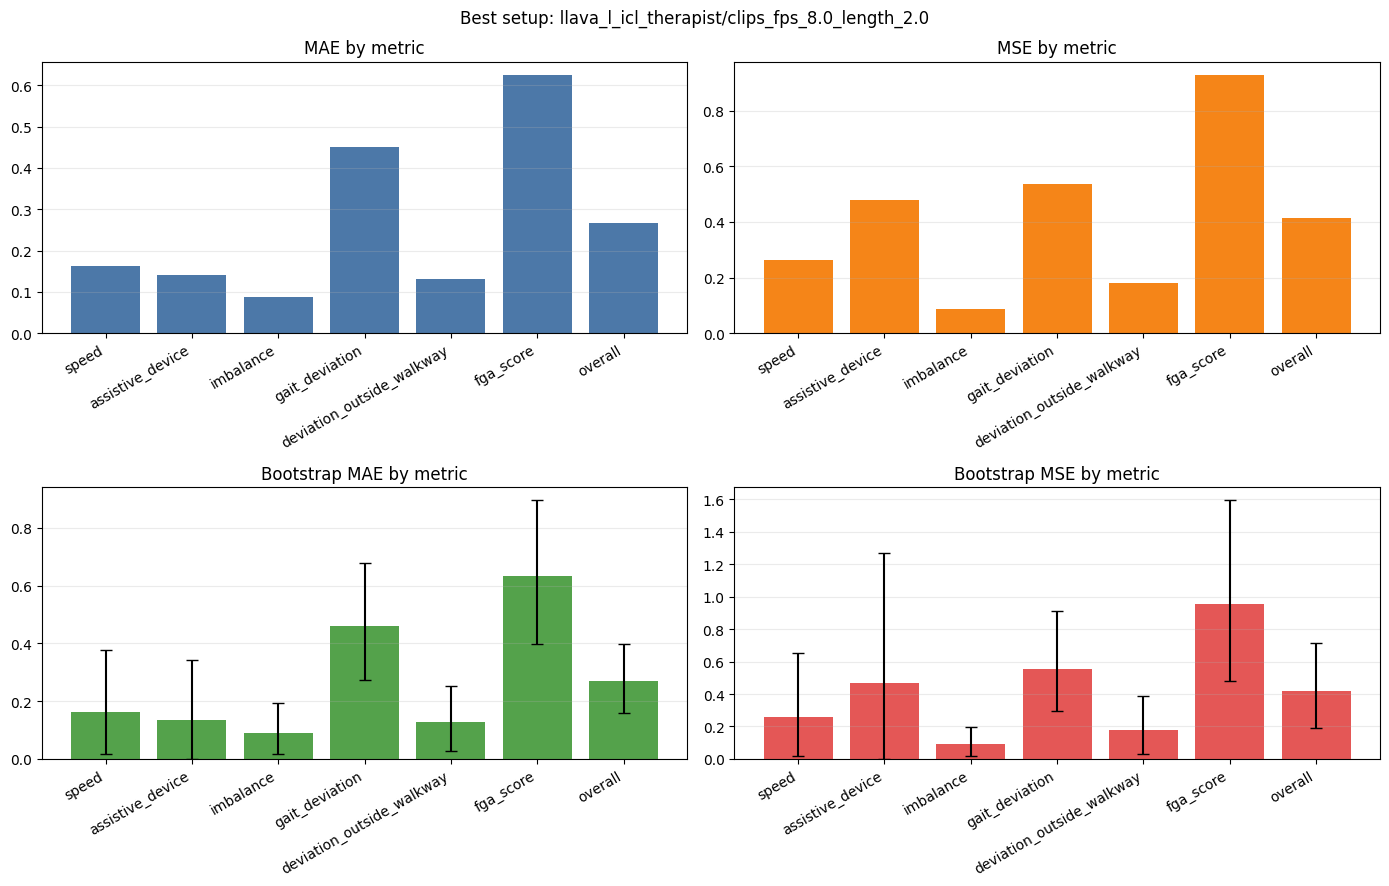

In [48]:
# ========= BEST setup metrics =========

# Reuse shared helper so this cell stays focused on interpretation
panel = metric_panel_data_for_setup(BEST_SETUP_ID)
plot_metric_panels(panel, f"Best setup: {BEST_SETUP_ID}")

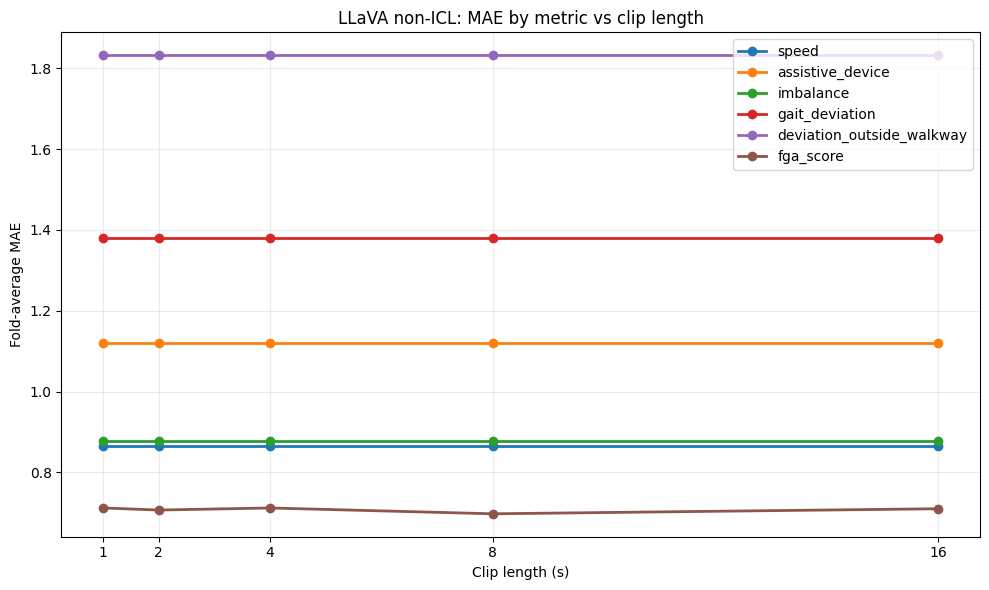

In [49]:
# ========= LLaVA per-metric MAE vs clip length =========

setup_target = "llava_l_noicl_therapist"
sub = get_setup_rows(setup_target)
lengths = sub["length"].astype(float).tolist()

plt.figure(figsize=(10, 6))
for f in FIELDS:
    ys = [row[f] for row in sub["mae_by_field"]]
    plt.plot(lengths, ys, marker="o", linewidth=2, label=f)

plt.xlabel("Clip length (s)")
plt.ylabel("Fold-average MAE")
plt.title("LLaVA non-ICL: MAE by metric vs clip length")
plt.xticks(lengths)
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

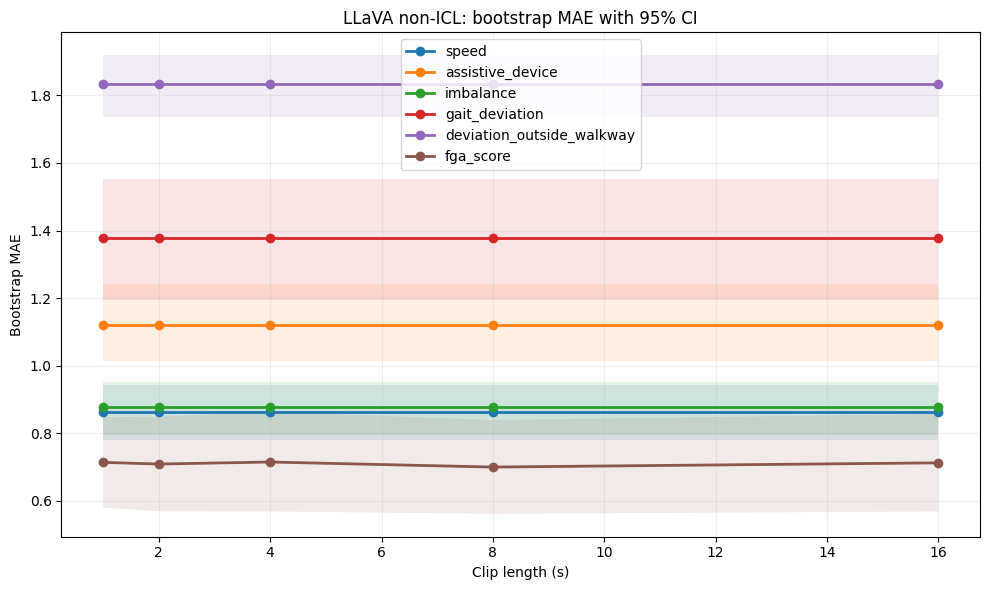

In [50]:
# ========= LLaVA bootstrap MAE vs clip length with 95% CI =========

setup_target = "llava_l_noicl_therapist"
ci_df = bootstrap_mae_ci_by_length(setup_target)

plt.figure(figsize=(10, 6))
for f in FIELDS:
    d = ci_df[ci_df["metric"] == f].sort_values("length")
    plt.plot(d["length"], d["mean"], marker="o", linewidth=2, label=f)
    plt.fill_between(d["length"], d["lo"], d["hi"], alpha=0.12)

plt.xlabel("Clip length (s)")
plt.ylabel("Bootstrap MAE")
plt.title("LLaVA non-ICL: bootstrap MAE with 95% CI")
plt.grid(alpha=0.2)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

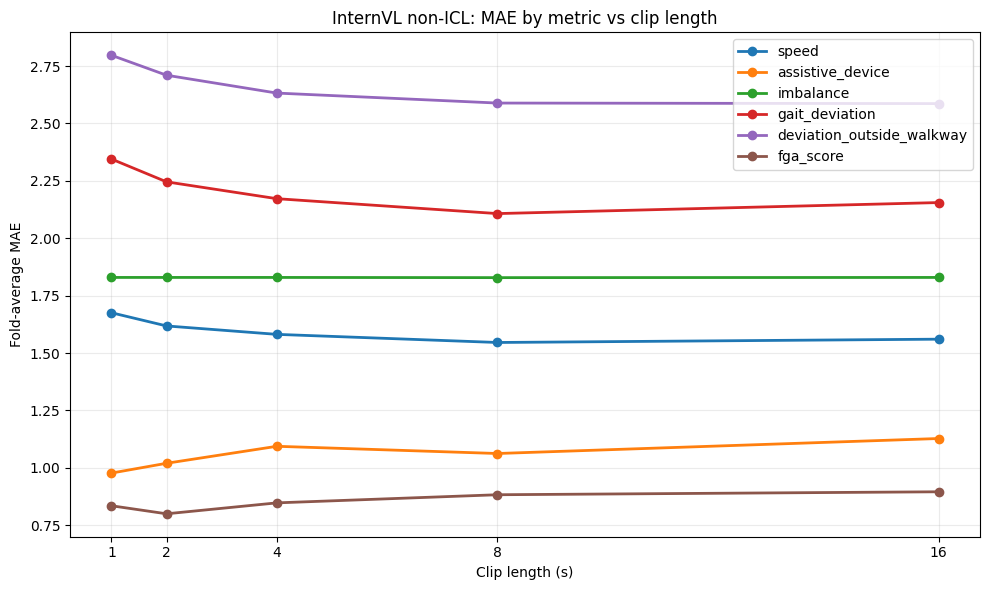

In [51]:
# ========= InternVL per-metric MAE vs clip length =========

setup_target = "intern_l_noicl_therapist"
sub = get_setup_rows(setup_target)
lengths = sub["length"].astype(float).tolist()

plt.figure(figsize=(10, 6))
for f in FIELDS:
    ys = [row[f] for row in sub["mae_by_field"]]
    plt.plot(lengths, ys, marker="o", linewidth=2, label=f)

plt.xlabel("Clip length (s)")
plt.ylabel("Fold-average MAE")
plt.title("InternVL non-ICL: MAE by metric vs clip length")
plt.xticks(lengths)
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

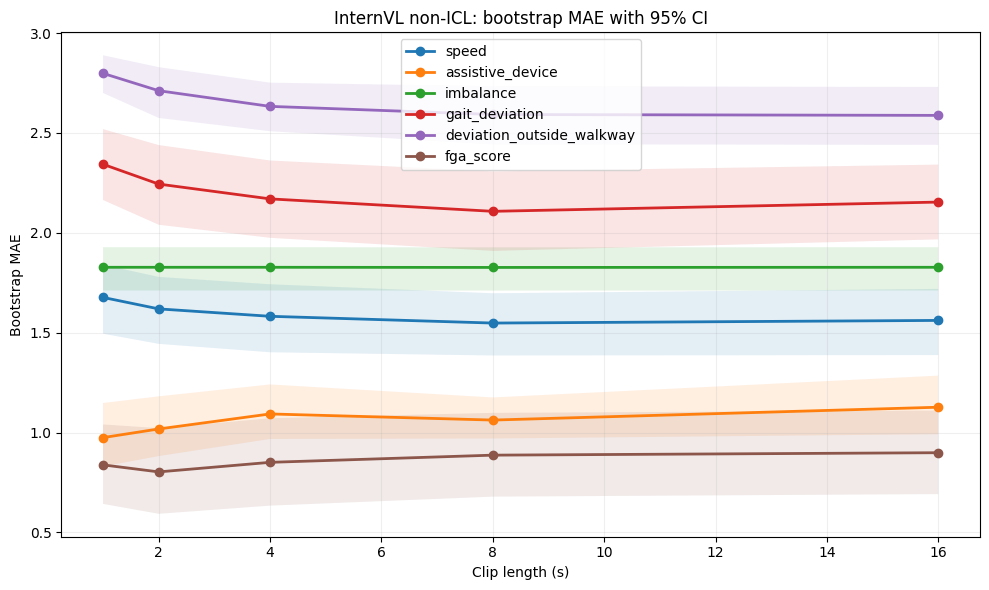

In [52]:
# ========= InternVL bootstrap MAE vs clip length with 95% CI =========

setup_target = "intern_l_noicl_therapist"
ci_df = bootstrap_mae_ci_by_length(setup_target)

plt.figure(figsize=(10, 6))
for f in FIELDS:
    d = ci_df[ci_df["metric"] == f].sort_values("length")
    plt.plot(d["length"], d["mean"], marker="o", linewidth=2, label=f)
    plt.fill_between(d["length"], d["lo"], d["hi"], alpha=0.12)

plt.xlabel("Clip length (s)")
plt.ylabel("Bootstrap MAE")
plt.title("InternVL non-ICL: bootstrap MAE with 95% CI")
plt.grid(alpha=0.2)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

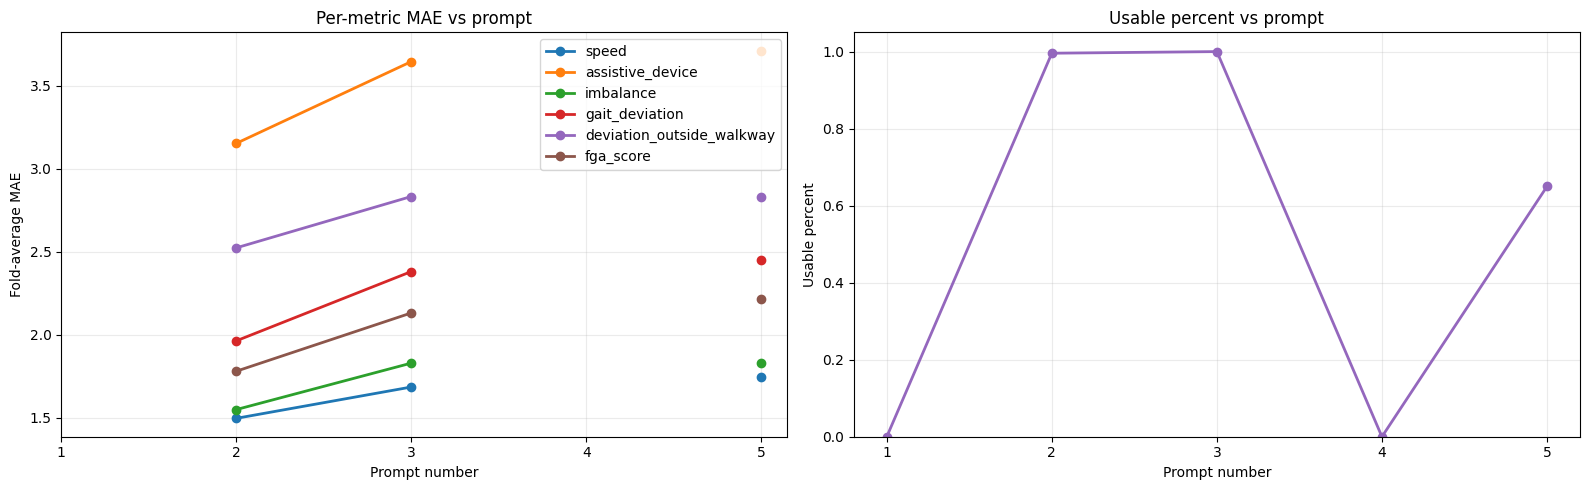

In [53]:
# ========= Prompt study: per-metric MAE + usable pct vs prompt =========

def prompt_number_from_setup_name(name):
    m = re.match(r"^llava_l_noicl_therapist(\d+)$", str(name))
    return int(m.group(1)) if m else None

sub = RESULTS_DF.copy()
sub["prompt_n"] = sub["setup_name"].map(prompt_number_from_setup_name)
sub = sub[sub["prompt_n"].notna()].copy()
sub = sub.sort_values(["prompt_n", "overall_mae", "overall_mse"]).groupby("prompt_n", as_index=False).first().sort_values("prompt_n")

x = sub["prompt_n"].astype(int).tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for f in FIELDS:
    ys = [row[f] for row in sub["mae_by_field"]]
    axes[0].plot(x, ys, marker="o", linewidth=2, label=f)
axes[0].set_title("Per-metric MAE vs prompt")
axes[0].set_xlabel("Prompt number")
axes[0].set_ylabel("Fold-average MAE")
axes[0].set_xticks(x)
axes[0].grid(alpha=0.25)
axes[0].legend(loc="best")

axes[1].plot(x, sub["usable_pct"].astype(float), marker="o", linewidth=2, color="#9467BD")
axes[1].set_title("Usable percent vs prompt")
axes[1].set_xlabel("Prompt number")
axes[1].set_ylabel("Usable percent")
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(x)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

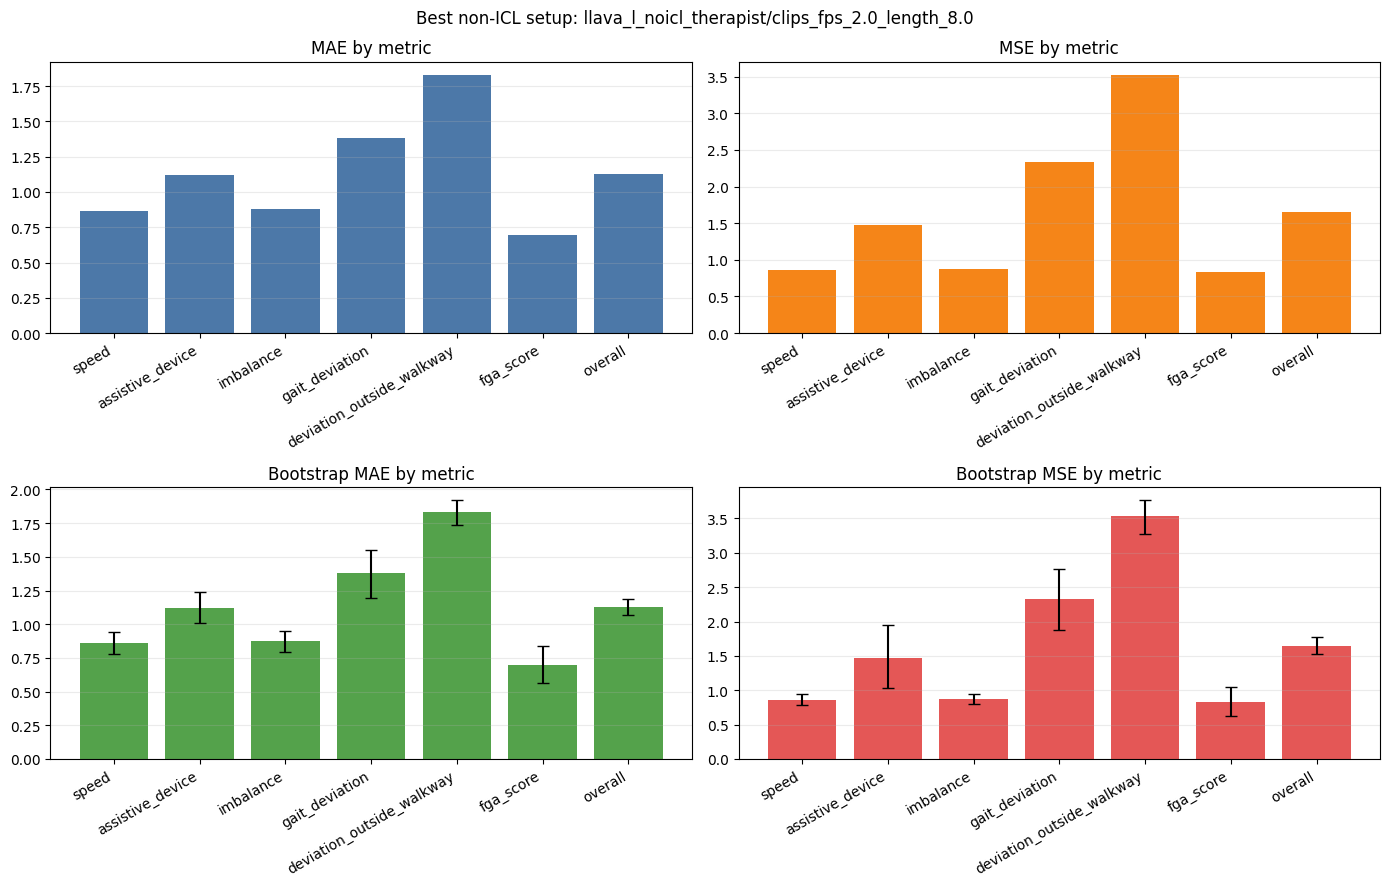

In [54]:
# ========= BEST non-ICL setup metrics =========

non_icl = RESULTS_DF[RESULTS_DF["setup_name"].str.contains("noicl", na=False)].copy()
BEST_NON_ICL_ROW = non_icl.sort_values(["overall_mae", "overall_mse", "setup_id"]).iloc[0].copy()
BEST_NON_ICL_SETUP_ID = str(BEST_NON_ICL_ROW["setup_id"])

panel = metric_panel_data_for_setup(BEST_NON_ICL_SETUP_ID)
plot_metric_panels(panel, f"Best non-ICL setup: {BEST_NON_ICL_SETUP_ID}")

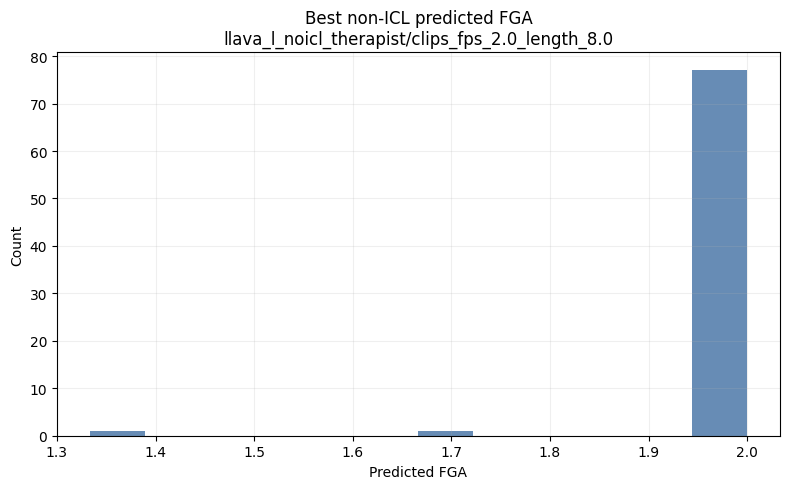

In [55]:
# ========= Histogram: predicted FGA for best non-ICL =========

# This should line up with the best non-ICL setup shown immediately above
pred_map = EVAL_CACHE[BEST_NON_ICL_SETUP_ID]["pred_map"]
ids = scored_sample_ids_for_setup(BEST_NON_ICL_SETUP_ID)
fga_pred = [pred_map[sid]["fga_score"] for sid in ids if not math.isnan(GT_MAP[sid]["fga_score"])]

plt.figure(figsize=(8, 5))
plt.hist(fga_pred, bins=12, color="#4C78A8", alpha=0.85)
plt.xlabel("Predicted FGA")
plt.ylabel("Count")
plt.title(f"Best non-ICL predicted FGA\n{BEST_NON_ICL_SETUP_ID}")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

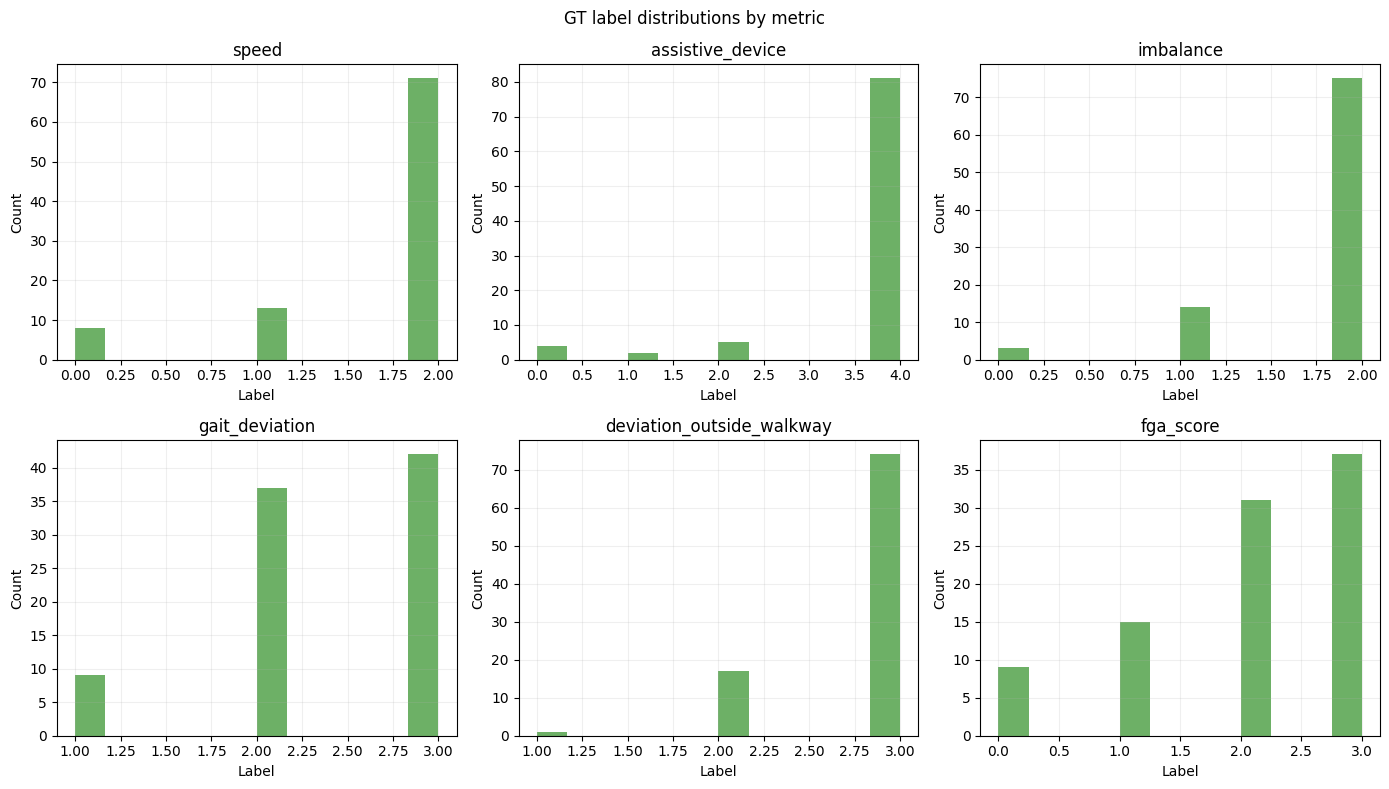

In [56]:
# ========= Histogram: GT labels for each metric =========

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, f in enumerate(FIELDS):
    vals = GT_DF[f].dropna().to_numpy(dtype=float)
    axes[i].hist(vals, bins=12, color="#54A24B", alpha=0.85)
    axes[i].set_title(f)
    axes[i].set_xlabel("Label")
    axes[i].set_ylabel("Count")
    axes[i].grid(alpha=0.2)

plt.suptitle("GT label distributions by metric")
plt.tight_layout()
plt.show()

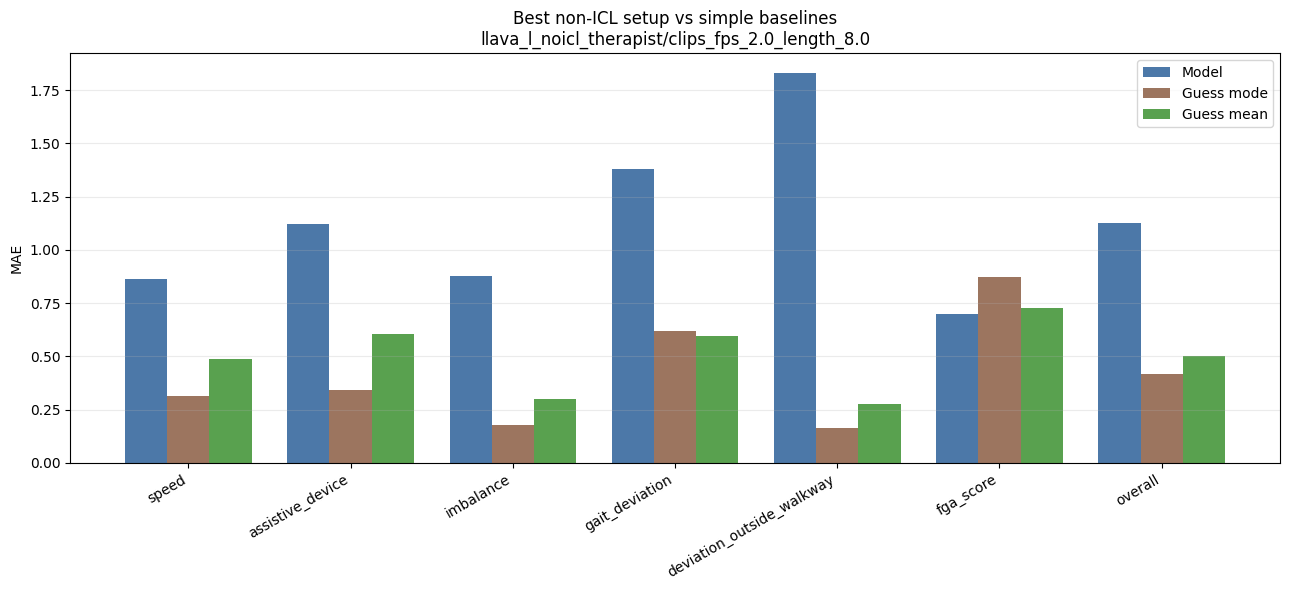

In [57]:
# ========= Model vs baselines (mode + mean) =========

# Compare the chosen non-ICL model against two simple GT-only baselines
best_non = EVAL_CACHE[BEST_NON_ICL_SETUP_ID]["fold_avg"]
model_mae = {f: best_non["mae_by_field"][f] for f in FIELDS}
model_mae["overall"] = best_non["overall_mae"]

mode_mae = baseline_mae_for_setup(BEST_NON_ICL_SETUP_ID, kind="mode")
mean_mae = baseline_mae_for_setup(BEST_NON_ICL_SETUP_ID, kind="mean")

labels = FIELDS + ["overall"]
x = np.arange(len(labels))
width = 0.26

plt.figure(figsize=(13, 6))
plt.bar(x - width, [model_mae[k] for k in labels], width=width, label="Model", color="#4C78A8")
plt.bar(x, [mode_mae[k] for k in labels], width=width, label="Guess mode", color="#9C755F")
plt.bar(x + width, [mean_mae[k] for k in labels], width=width, label="Guess mean", color="#59A14F")

plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("MAE")
plt.title(f"Best non-ICL setup vs simple baselines\n{BEST_NON_ICL_SETUP_ID}")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()